# 🎨 Artistic QR Code Generator - Fresh & Clean

Generate beautiful, scannable QR codes with AI art using Stable Diffusion + ControlNet.

**Based on:** 
- [Hugging Face QR Code AI Art Generator](https://huggingface.co/spaces/huggingface-projects/QR-code-AI-art-generator)
- [QR Code AI](https://qrcode-ai.com/) - Industry standard

## Features

- ✅ **ControlNet Integration**: Uses `monster-labs/control_v1p_sd15_qrcode_monster`
- ✅ **Scannable QR Codes**: QR codes remain fully functional
- ✅ **Scannability Validation**: Tests QR codes (High/Medium/Low/No Scannability)
- ✅ **Colorful Results**: Optimized for vibrant anime-style characters
- ✅ **Kaggle Ready**: Works with Kaggle's GPU environment


In [46]:
# Install dependencies
!pip install -q diffusers>=0.21.0 transformers>=4.30.0 accelerate>=0.20.0
!pip install -q qrcode[pil]>=7.4.2 Pillow>=10.0.0
!pip install -q pyzbar opencv-python xformers

print("✓ Dependencies installed!")


✓ Dependencies installed!


In [47]:
# Import and setup
import os
import qrcode
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from typing import Optional
import matplotlib.pyplot as plt

# QR validation
try:
    from pyzbar.pyzbar import decode as pyzbar_decode
    PYZBAR_AVAILABLE = True
except ImportError:
    PYZBAR_AVAILABLE = False

try:
    import cv2
    OPENCV_AVAILABLE = True
except ImportError:
    OPENCV_AVAILABLE = False

# Kaggle paths
KAGGLE_WORKING = "/kaggle/working"
KAGGLE_CACHE = "/kaggle/working/.cache"
os.makedirs(KAGGLE_WORKING, exist_ok=True)
os.makedirs(KAGGLE_CACHE, exist_ok=True)

os.environ["HF_HOME"] = KAGGLE_CACHE
os.environ["HF_HUB_CACHE"] = os.path.join(KAGGLE_CACHE, "hub")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")
print(f"✓ QR Validation: {'Available' if (PYZBAR_AVAILABLE or OPENCV_AVAILABLE) else 'Limited'}")


✓ Device: cuda
✓ QR Validation: Available


## ArtisticQRPipeline Class


In [48]:
class ArtisticQRPipeline:
    """Complete pipeline for generating artistic QR codes."""
    
    def __init__(self, model_id="runwayml/stable-diffusion-v1-5", cache_dir=None, device=None):
        self.model_id = model_id
        self.cache_dir = cache_dir or KAGGLE_CACHE
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.controlnet_pipe = None
        self.controlnet_model = None
        
    def create_qr_code(self, data: str, size: int = 512) -> Image.Image:
        """Create QR code."""
        qr = qrcode.QRCode(version=1, error_correction=qrcode.constants.ERROR_CORRECT_H, box_size=10, border=4)
        qr.add_data(data)
        qr.make(fit=True)
        qr_img = qr.make_image(fill_color="black", back_color="white")
        return qr_img.resize((size, size), Image.Resampling.LANCZOS)
    
    def load_controlnet_model(self):
        """Load ControlNet model."""
        if self.controlnet_pipe is not None:
            return self.controlnet_pipe
        
        print("Loading ControlNet QR code model...")
        dtype = torch.float16 if self.device == "cuda" else torch.float32
        
        controlnet_models = [
            "monster-labs/control_v1p_sd15_qrcode_monster",
            "DionTimmer/controlnet_qrcode-control_v11p_sd15",
        ]
        
        controlnet = None
        for model_id in controlnet_models:
            try:
                print(f"Trying: {model_id}")
                controlnet = ControlNetModel.from_pretrained(model_id, torch_dtype=dtype, cache_dir=self.cache_dir)
                print(f"✓ Loaded: {model_id}")
                self.controlnet_model = model_id
                break
            except Exception as e:
                print(f"Failed: {e}")
                continue
        
        if controlnet is None:
            raise RuntimeError("Could not load ControlNet model")
        
        self.controlnet_pipe = StableDiffusionControlNetPipeline.from_pretrained(
            self.model_id, controlnet=controlnet, torch_dtype=dtype, cache_dir=self.cache_dir,
            safety_checker=None, requires_safety_checker=False
        ).to(self.device)
        
        if self.device == "cuda":
            try:
                self.controlnet_pipe.enable_xformers_memory_efficient_attention()
            except:
                pass
        
        return self.controlnet_pipe
    
    def enhance_qr_scannability(self, generated_image: Image.Image, qr_reference: Image.Image, enhancement_strength: float = 0.15) -> Image.Image:
        """Enhance QR scannability."""
        if generated_image.mode != 'RGB':
            generated_image = generated_image.convert('RGB')
        if qr_reference.mode != 'RGB':
            qr_reference = qr_reference.convert('RGB')
        
        target_size = generated_image.size[0]
        qr_reference = qr_reference.resize((target_size, target_size), Image.Resampling.LANCZOS)
        
        gen_array = np.array(generated_image, dtype=float)
        qr_array = np.array(qr_reference, dtype=float)
        
        qr_gray = np.dot(qr_array[...,:3], [0.2989, 0.5870, 0.1140])
        qr_binary = (qr_gray < 127).astype(float)
        qr_mask_3d = np.expand_dims(qr_binary, axis=2)
        
        result_array = gen_array.copy()
        
        dark_mask = qr_mask_3d
        darken_factor = 1.0 - (enhancement_strength * 0.5)
        result_array = result_array * (1 - dark_mask * (1 - darken_factor))
        
        light_mask = 1 - qr_mask_3d
        lighten_factor = 1.0 + (enhancement_strength * 0.5)
        result_array = result_array * (1 + light_mask * (lighten_factor - 1))
        
        contrast_boost = enhancement_strength * 30
        qr_contrast = (qr_mask_3d - 0.5) * 2
        result_array = result_array + (qr_contrast * contrast_boost)
        
        result_array = np.clip(result_array, 0, 255).astype(np.uint8)
        return Image.fromarray(result_array)
    
    def validate_scannability(self, image_path: str, expected_data: str = None) -> dict:
        """Validate QR scannability (like QR Code AI)."""
        result = {'scannable': False, 'scannability_level': 'No Scannable', 'data_decoded': None, 'confidence': 0.0}
        
        try:
            img = Image.open(image_path)
            
            if PYZBAR_AVAILABLE:
                try:
                    img_array = np.array(img.convert('RGB'))
                    decoded_objects = pyzbar_decode(img_array)
                    if decoded_objects:
                        for obj in decoded_objects:
                            if obj.type == 'QRCODE':
                                decoded = obj.data.decode('utf-8')
                                result['scannable'] = True
                                result['data_decoded'] = decoded
                                result['confidence'] = 1.0 if (expected_data and decoded == expected_data) else 0.9
                                break
                except:
                    pass
            
            if not result['scannable'] and OPENCV_AVAILABLE:
                try:
                    img_cv = cv2.imread(image_path)
                    if img_cv is not None:
                        detector = cv2.QRCodeDetector()
                        retval, decoded_info, points, _ = detector.detectAndDecodeMulti(img_cv)
                        if retval and decoded_info:
                            for info in decoded_info:
                                if info:
                                    result['scannable'] = True
                                    result['data_decoded'] = info
                                    result['confidence'] = 1.0 if (expected_data and info == expected_data) else 0.8
                                    break
                except:
                    pass
            
            if result['scannable']:
                if result['confidence'] >= 0.95:
                    result['scannability_level'] = 'High Scannability'
                elif result['confidence'] >= 0.8:
                    result['scannability_level'] = 'Medium Scannability'
                else:
                    result['scannability_level'] = 'Low Scannability'
        except Exception as e:
            result['error'] = str(e)
        
        return result
    
    def generate_with_controlnet(self, prompt: str, qr_data: str, output_path: str = None, image_size: int = 512,
                                 num_inference_steps: int = 50, guidance_scale: float = 11.0,
                                 controlnet_conditioning_scale: float = 1.1, seed: Optional[int] = None,
                                 negative_prompt: str = "black and white, grayscale, monochrome, desaturated, dull colors, abstract pattern, no character, blurry, distorted, unreadable qr, low quality",
                                 qr_enhancement_strength: float = 0.08) -> Image.Image:
        """Generate artistic QR code."""
        print("=" * 60)
        print("ControlNet Artistic QR Code Generation")
        print("=" * 60)
        
        print("\n[Step 1/3] Creating QR code...")
        qr_image = self.create_qr_code(qr_data, size=image_size).convert("RGB")
        print(f"✓ QR code created: {image_size}x{image_size}")
        
        print("\n[Step 2/3] Loading ControlNet model...")
        pipe = self.load_controlnet_model()
        
        print(f"\n[Step 3/3] Generating image...")
        print(f"Prompt: {prompt[:80]}...")
        
        generator = None
        if seed is not None:
            generator = torch.Generator(device=self.device).manual_seed(seed)
        
        image = pipe(
            prompt=prompt, negative_prompt=negative_prompt, image=qr_image,
            num_inference_steps=num_inference_steps, guidance_scale=guidance_scale,
            controlnet_conditioning_scale=controlnet_conditioning_scale, generator=generator
        ).images[0]
        
        print("Enhancing QR scannability...")
        image = self.enhance_qr_scannability(image, qr_image, enhancement_strength=qr_enhancement_strength)
        
        if output_path:
            image.save(output_path)
            print(f"\n✓ Saved to: {output_path}")
        
        return image

print("✓ ArtisticQRPipeline class defined!")


✓ ArtisticQRPipeline class defined!


In [49]:
# Initialize pipeline
pipeline = ArtisticQRPipeline(model_id="runwayml/stable-diffusion-v1-5", cache_dir=KAGGLE_CACHE)
print("✓ Pipeline initialized!")


✓ Pipeline initialized!


## Generate Colorful Anime Character QR Code


ControlNet Artistic QR Code Generation

[Step 1/3] Creating QR code...
✓ QR code created: 512x512

[Step 2/3] Loading ControlNet model...
Loading ControlNet QR code model...
Trying: monster-labs/control_v1p_sd15_qrcode_monster


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


✓ Loaded: monster-labs/control_v1p_sd15_qrcode_monster


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /kaggle/working/.cache/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (84 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', qr code pattern integrated into colorful background landscape']



[Step 3/3] Generating image...
Prompt: 1girl, anime style, colorful character portrait, white hair with black and gold ...


  0%|          | 0/50 [00:00<?, ?it/s]

Enhancing QR scannability...

✓ Saved to: /kaggle/working/anime_character_qr.png


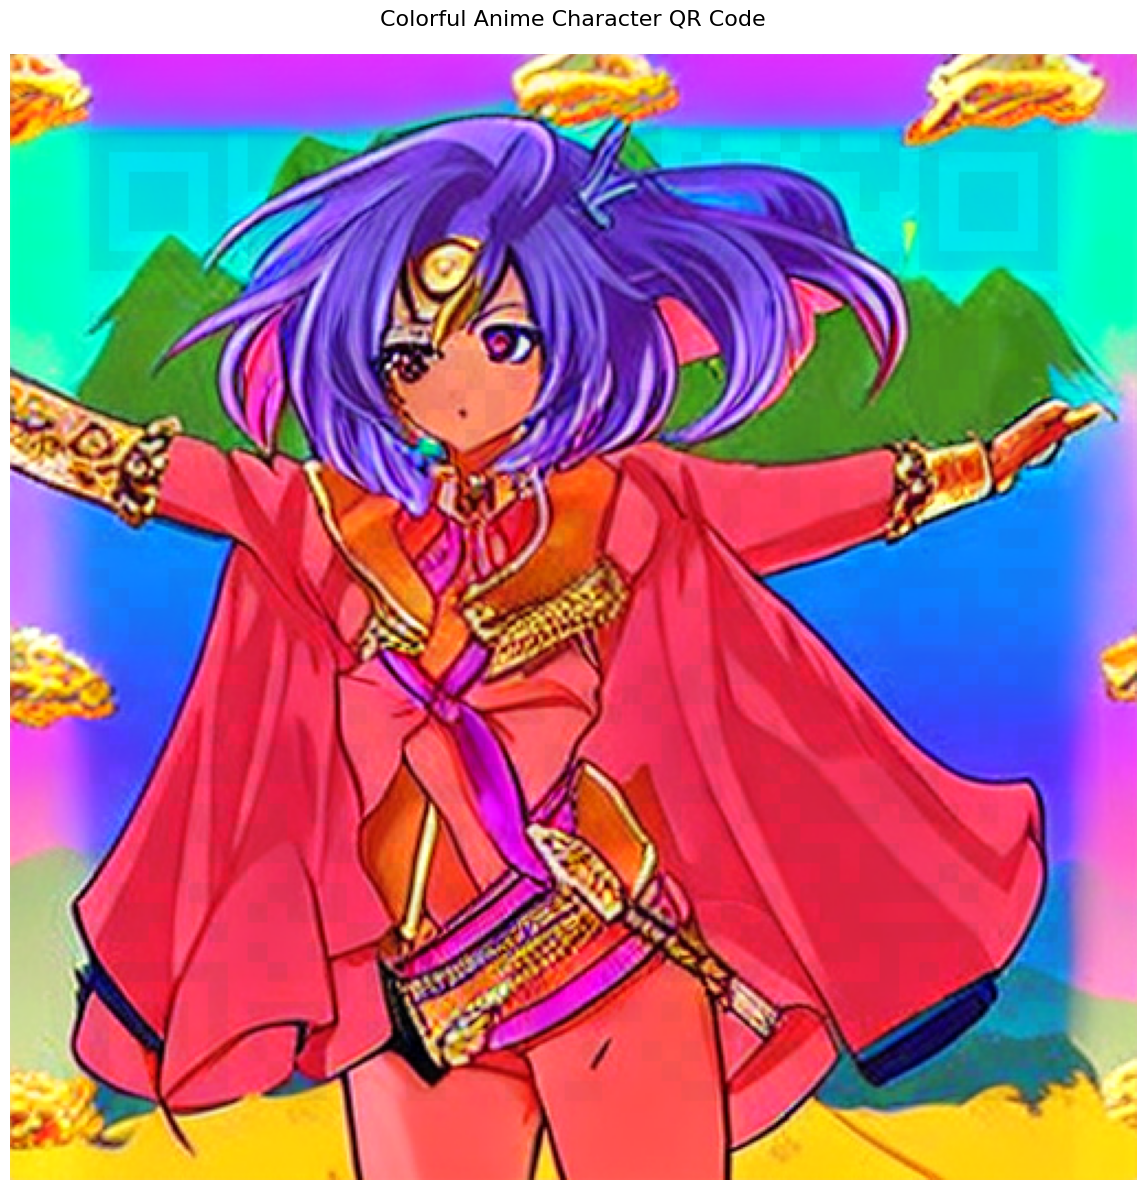


QR Code Scannability Validation

Scannability: ❌ No Scannable
❌ QR Code may not be scannable

✓ Saved to: /kaggle/working/anime_character_qr.png


In [ ]:
# Generate colorful anime character QR code
# FIXED: Shorter prompt (under 77 tokens for CLIP), better parameters for scannability
prompt = "1girl, anime style, colorful character portrait, white hair with black and gold patterns, vibrant colorful elegant dark outfit with gold and red accents, standing pose, vibrant blue sky with colorful stylized mountain peaks, highly detailed colorful face, beautiful colorful eyes, vibrant colors, rich saturated colors, anime illustration style, masterpiece, best quality, QR code pattern integrated into background"

qr_data = "https://huggingface.co/spaces/huggingface-projects/QR-code-AI-art-generator"

output_image = pipeline.generate_with_controlnet(
    prompt=prompt,
    qr_data=qr_data,
    output_path=f"{KAGGLE_WORKING}/anime_character_qr.png",
    image_size=512,
    num_inference_steps=50,
    guidance_scale=11.0,
    controlnet_conditioning_scale=1.2,  # INCREASED: Better QR structure (was 1.1)
    seed=789,  # Try: 42, 123, 456, 789, 1000, 2024
    negative_prompt="black and white, grayscale, monochrome, desaturated, dull colors, muted colors, sepia, abstract, pattern, floral, organic shapes, no character, no person, no face, landscape only, blurry, distorted, unreadable qr, low quality, bad anatomy",
    qr_enhancement_strength=0.10  # INCREASED: Better QR visibility (was 0.08)
)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(output_image)
plt.axis('off')
plt.title('Colorful Anime Character QR Code', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Validate scannability (like QR Code AI)
print("\n" + "=" * 60)
print("QR Code Scannability Validation")
print("=" * 60)
validation = pipeline.validate_scannability(f"{KAGGLE_WORKING}/anime_character_qr.png", expected_data=qr_data)

scannability_icons = {
    'High Scannability': '✅',
    'Medium Scannability': '⚠️',
    'Low Scannability': '⚠️',
    'No Scannable': '❌'
}

print(f"\nScannability: {scannability_icons.get(validation['scannability_level'], '')} {validation['scannability_level']}")
if validation['scannable']:
    print(f"✓ QR Code is SCANNABLE!")
    if validation['data_decoded']:
        print(f"  Decoded: {validation['data_decoded'][:60]}...")
    print(f"  Confidence: {validation['confidence']:.2f}")
else:
    print(f"❌ QR Code may not be scannable")

print(f"\n✓ Saved to: {KAGGLE_WORKING}/anime_character_qr.png")


## Alternative: Shorter Prompt for Better Scannability

If the QR code is still not scannable, try this version with a shorter, more focused prompt.


In [ ]:
# Alternative: Shorter prompt optimized for scannability
# This prompt is shorter (under 60 tokens) and focuses on essential elements

prompt = "1girl, anime style, colorful character portrait, white hair with black gold patterns, elegant dark outfit with gold red accents, vibrant blue sky with mountain peaks, detailed colorful face, vibrant colors, anime illustration, masterpiece, QR code pattern in background"

qr_data = "https://huggingface.co/spaces/huggingface-projects/QR-code-AI-art-generator"

# Optimized for scannability
output_image = pipeline.generate_with_controlnet(
    prompt=prompt,
    qr_data=qr_data,
    output_path=f"{KAGGLE_WORKING}/anime_character_qr_v2.png",
    image_size=512,
    num_inference_steps=50,
    guidance_scale=11.0,
    controlnet_conditioning_scale=1.3,  # Higher for better QR scannability
    seed=123,  # Different seed
    negative_prompt="black and white, grayscale, monochrome, desaturated, dull colors, abstract pattern, no character, blurry, distorted, unreadable qr, low quality",
    qr_enhancement_strength=0.12  # Higher for better QR visibility
)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(output_image)
plt.axis('off')
plt.title('Anime Character QR Code (Optimized for Scannability)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Validate
print("\n" + "=" * 60)
print("QR Code Scannability Validation")
print("=" * 60)
validation = pipeline.validate_scannability(f"{KAGGLE_WORKING}/anime_character_qr_v2.png", expected_data=qr_data)

scannability_icons = {
    'High Scannability': '✅',
    'Medium Scannability': '⚠️',
    'Low Scannability': '⚠️',
    'No Scannable': '❌'
}

print(f"\nScannability: {scannability_icons.get(validation['scannability_level'], '')} {validation['scannability_level']}")
if validation['scannable']:
    print(f"✓ QR Code is SCANNABLE!")
    if validation['data_decoded']:
        print(f"  Decoded: {validation['data_decoded'][:60]}...")
    print(f"  Confidence: {validation['confidence']:.2f}")
else:
    print(f"❌ QR Code may not be scannable")
    print(f"  Try increasing controlnet_conditioning_scale to 1.4-1.5")

print(f"\n✓ Saved to: {KAGGLE_WORKING}/anime_character_qr_v2.png")


## Parameter Guide

### ⚠️ IMPORTANT: Prompt Length Limit

**CLIP can only handle 77 tokens!** Keep prompts under 77 tokens or they'll be truncated.

**How to check:** Count words in your prompt (roughly 1 word = 1 token)

### Best Settings for Colorful Anime Characters (SCANNABLE):

- **`num_inference_steps`**: 50 (more detail)
- **`guidance_scale`**: 11.0-12.0 (forces character and colors)
- **`controlnet_conditioning_scale`**: **1.2-1.3** (balanced for character + scannable QR)
- **`qr_enhancement_strength`**: **0.10-0.12** (better QR visibility)
- **`seed`**: Try 42, 123, 456, 789, 1000, 2024

### Prompt Tips (Keep Under 77 Tokens):

- Start with: `"1girl, anime style, colorful character portrait"`
- Add: `"vibrant colors"`, `"rich saturated colors"` (don't repeat too much)
- Exclude: `"black and white"`, `"grayscale"`, `"monochrome"` in negative prompt
- Describe colors: `"gold accents"`, `"red markings"`, `"blue sky"`
- **Remove redundant words** to stay under 77 tokens

### Troubleshooting:

**QR not scannable?** 
- ✅ Increase `controlnet_conditioning_scale` to **1.2-1.3** (current: 1.2)
- ✅ Increase `qr_enhancement_strength` to **0.10-0.12** (current: 0.10)
- ✅ Shorten prompt (remove redundant color words)

**Character too abstract?** 
- Lower `controlnet_conditioning_scale` to 1.0-1.1, increase `guidance_scale` to 12.0-13.0
- **Trade-off:** Better character = QR might be less scannable

**Black & white?** 
- Add color keywords to prompt, exclude grayscale in negative prompt, try different seeds

**Prompt too long?**
- Remove redundant words like "colorful" repeated multiple times
- Keep essential: character description, colors, background, QR mention
